In [2]:
import pandas as pd
import numpy as np

In [4]:
import os

os.getcwd()

'C:\\Users\\sreel\\Downloads\\Retail_Sales_Analysis'

In [6]:
os.listdir()

['.ipynb_checkpoints', 'Global_Superstore.csv', 'Retail_Sales_Analysis.ipynb']

In [7]:
df = pd.read_csv("Global_Superstore.csv", encoding="latin1")

In [8]:
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,è®°å½æ°,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   è®°å½æ°       51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [10]:
df.shape

(51290, 27)

In [11]:
df.columns

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', 'è®°å½æ°', 'Order.Date', 'Order.ID',
       'Order.Priority', 'Product.ID', 'Product.Name', 'Profit', 'Quantity',
       'Region', 'Row.ID', 'Sales', 'Segment', 'Ship.Date', 'Ship.Mode',
       'Shipping.Cost', 'State', 'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')

In [12]:
df.isnull().sum()

Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
è®°å½æ°         0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     0
State             0
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.dtypes

Category           object
City               object
Country            object
Customer.ID        object
Customer.Name      object
Discount          float64
Market             object
è®°å½æ°           int64
Order.Date         object
Order.ID           object
Order.Priority     object
Product.ID         object
Product.Name       object
Profit            float64
Quantity            int64
Region             object
Row.ID              int64
Sales               int64
Segment            object
Ship.Date          object
Ship.Mode          object
Shipping.Cost     float64
State              object
Sub.Category       object
Year                int64
Market2            object
weeknum             int64
dtype: object

In [15]:
df["Order.Date"] = pd.to_datetime(df["Order.Date"])
df["Ship.Date"] = pd.to_datetime(df["Ship.Date"])

In [16]:
df[["Order.Date", "Ship.Date"]].dtypes

Order.Date    datetime64[ns]
Ship.Date     datetime64[ns]
dtype: object

In [17]:
total_sales = df["Sales"].sum()
total_sales

np.int64(12642905)

In [18]:
total_profit = df["Profit"].sum()
total_profit

np.float64(1467457.2912800002)

In [19]:
total_quantity = df["Quantity"].sum()
total_quantity

np.int64(178312)

In [20]:
top_products = (
    df.groupby("Product.Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product.Name
Apple Smart Phone, Full Size                                86936
Cisco Smart Phone, Full Size                                76441
Motorola Smart Phone, Full Size                             73159
Nokia Smart Phone, Full Size                                71904
Canon imageCLASS 2200 Advanced Copier                       61600
Hon Executive Leather Armchair, Adjustable                  58200
Office Star Executive Leather Armchair, Adjustable          50667
Harbour Creations Executive Leather Armchair, Adjustable    50120
Samsung Smart Phone, Cordless                               48654
Nokia Smart Phone, with Caller ID                           47880
Name: Sales, dtype: int64

<Axes: title={'center': 'Top 10 Products by Sales'}, ylabel='Product.Name'>

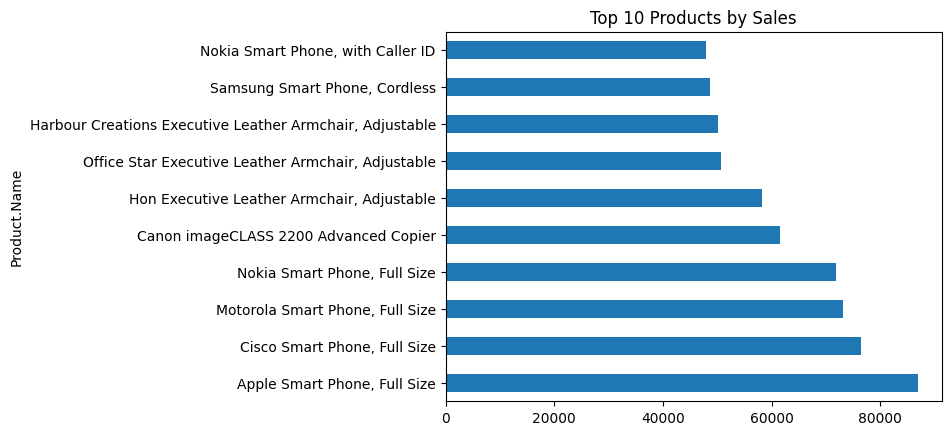

In [21]:
top_products.plot(kind="barh", title="Top 10 Products by Sales")

In [22]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Technology         4744691
Furniture          4110884
Office Supplies    3787330
Name: Sales, dtype: int64

<Axes: title={'center': 'Sales by Category'}, xlabel='Category', ylabel='Total Sales'>

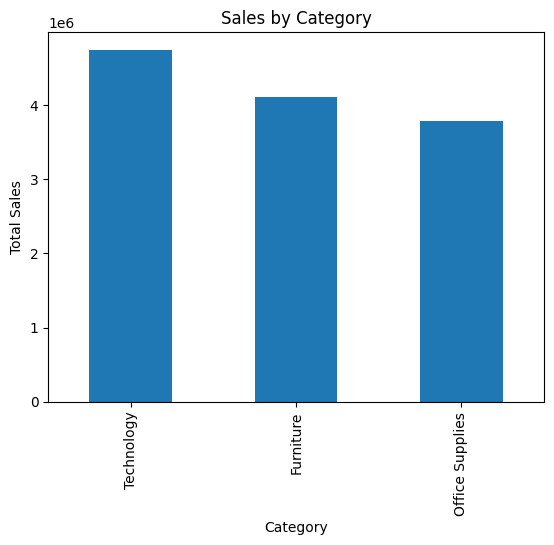

In [23]:
category_sales.plot(
    kind="bar",
    title="Sales by Category",
    xlabel="Category",
    ylabel="Total Sales"
)

In [24]:
subcategory_sales = (
    df.groupby("Sub.Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

subcategory_sales

Sub.Category
Phones         1706874
Copiers        1509439
Chairs         1501682
Bookcases      1466559
Storage        1127124
Appliances     1011081
Machines        779071
Tables          757034
Accessories     749307
Binders         461952
Furnishings     385609
Art             372163
Paper           244307
Supplies        243090
Envelopes       170926
Fasteners        83254
Labels           73433
Name: Sales, dtype: int64

<Axes: title={'center': 'Sales by Sub-Category'}, xlabel='Sub-Category', ylabel='Total Sales'>

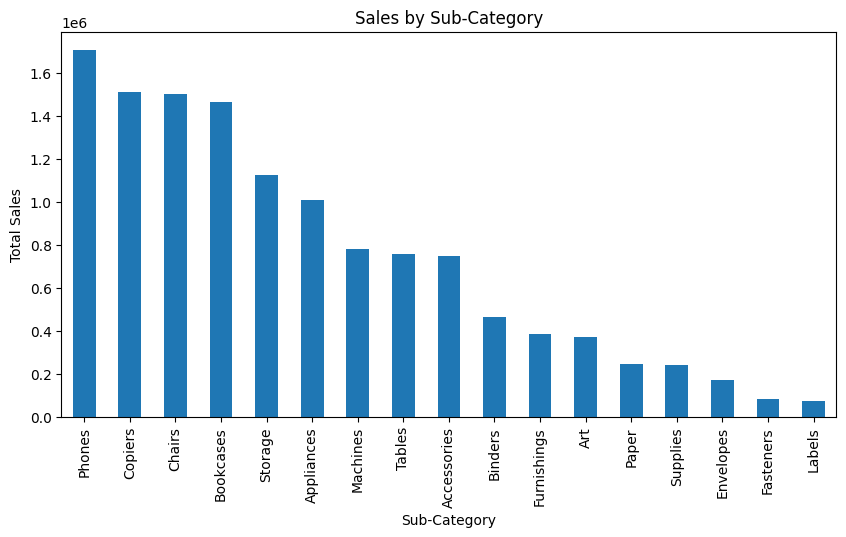

In [25]:
subcategory_sales.plot(
    kind="bar",
    figsize=(10, 5),
    title="Sales by Sub-Category",
    xlabel="Sub-Category",
    ylabel="Total Sales"
)

In [26]:
yearly_sales = (
    df.groupby("Year")["Sales"]
    .sum()
    .sort_index()
)

yearly_sales

Year
2011    2259511
2012    2677493
2013    3405860
2014    4300041
Name: Sales, dtype: int64

<Axes: title={'center': 'Yearly Sales Trend'}, xlabel='Year', ylabel='Total Sales'>

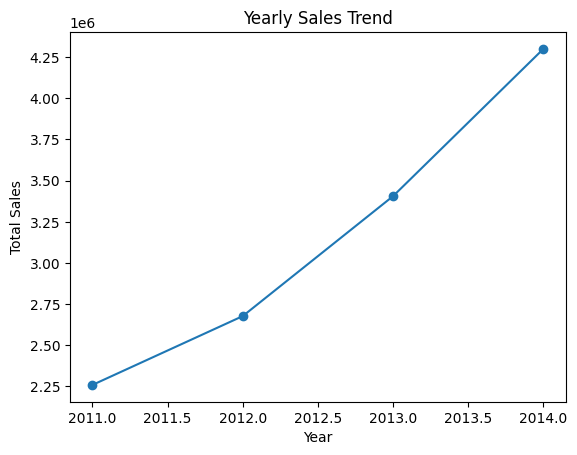

In [27]:
yearly_sales.plot(
    kind="line",
    marker="o",
    title="Yearly Sales Trend",
    xlabel="Year",
    ylabel="Total Sales"
)

In [28]:
df["Month"] = df["Order.Date"].dt.month

In [29]:
monthly_sales = (
    df.groupby("Month")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

monthly_sales

Month
12    1580816
11    1551319
9     1437432
8     1293852
6     1269751
10    1168220
5      904061
3      770519
7      749423
4      698603
1      675141
2      543768
Name: Sales, dtype: int64

In [30]:
df["Month_Name"] = df["Order.Date"].dt.month_name()

In [31]:
monthly_sales_name = (
    df.groupby("Month_Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

monthly_sales_name

Month_Name
December     1580816
November     1551319
September    1437432
August       1293852
June         1269751
October      1168220
May           904061
March         770519
July          749423
April         698603
January       675141
February      543768
Name: Sales, dtype: int64

In [32]:
df["Month"] = df["Order.Date"].dt.month
df["Month_Name"] = df["Order.Date"].dt.month_name()

In [33]:
monthly_sales = (
    df.groupby(["Month", "Month_Name"])["Sales"]
    .sum()
    .reset_index()
    .sort_values("Month")
)

monthly_sales

,Month,Month_Name,Sales
0,1,January,675141
1,2,February,543768
2,3,March,770519
3,4,April,698603
4,5,May,904061
5,6,June,1269751
6,7,July,749423
7,8,August,1293852
8,9,September,1437432
9,10,October,1168220


<Axes: title={'center': 'Monthly Sales Trend'}, xlabel='Month', ylabel='Total Sales'>

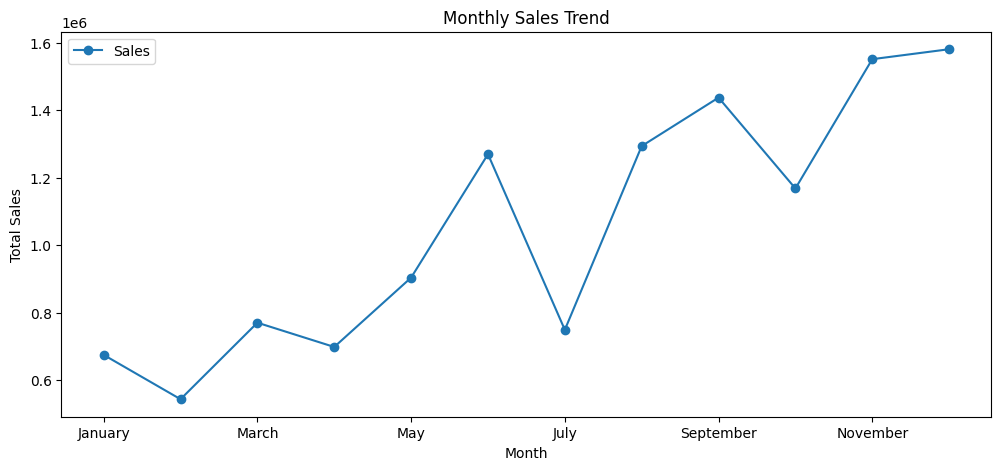

In [34]:
monthly_sales.plot(
    x="Month_Name",
    y="Sales",
    kind="line",
    marker="o",
    figsize=(12, 5),
    title="Monthly Sales Trend",
    xlabel="Month",
    ylabel="Total Sales"
)

In [35]:
peak_month = monthly_sales.loc[monthly_sales["Sales"].idxmax()]

peak_month

Month               12
Month_Name    December
Sales          1580816
Name: 11, dtype: object

In [36]:
lowest_month = monthly_sales.loc[monthly_sales["Sales"].idxmin()]

lowest_month

Month                2
Month_Name    February
Sales           543768
Name: 1, dtype: object

In [48]:
profit_by_category = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)
profit_by_category

Category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          285204.72380
Name: Profit, dtype: float64

In [45]:
profit_by_subcategory = (
    df.groupby("Sub.Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_subcategory

Sub.Category
Copiers        258567.54818
Phones         216717.00580
Bookcases      161924.41950
Appliances     141680.58940
Chairs         140396.26750
Accessories    129626.30620
Storage        108461.48980
Binders         72449.84600
Paper           59207.68270
Machines        58867.87300
Art             57953.91090
Furnishings     46967.42550
Envelopes       29601.11630
Supplies        22583.26310
Labels          15010.51200
Fasteners       11525.42410
Tables         -64083.38870
Name: Profit, dtype: float64

In [46]:
profit_by_region = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_region

Region
Central           311403.98164
North             194597.95252
North Asia        165578.42100
South             140355.76618
Central Asia      132480.18700
Oceania           120089.11200
West              108418.44890
East               91522.78000
Africa             88871.63100
EMEA               43897.97100
Caribbean          34571.32104
Southeast Asia     17852.32900
Canada             17817.39000
Name: Profit, dtype: float64

<Axes: title={'center': 'Profit by Category'}, xlabel='Category', ylabel='Total Profit'>

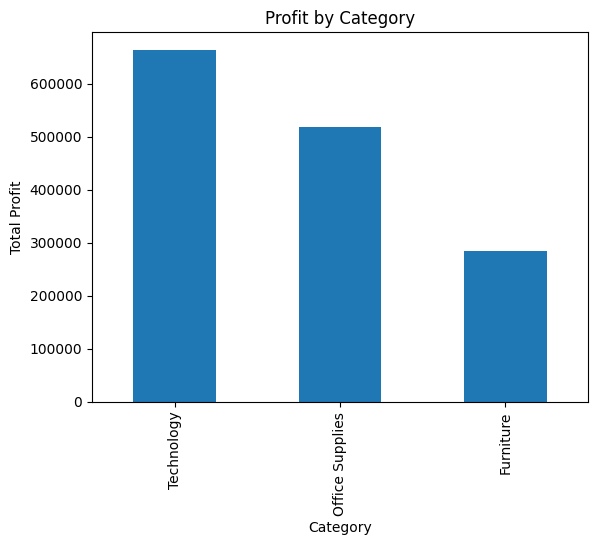

In [47]:
profit_by_category.plot(
    kind="bar",
    title="Profit by Category",
    xlabel="Category",
    ylabel="Total Profit"
)

<Axes: title={'center': 'Profit by Sub-Category'}, xlabel='Sub-Category', ylabel='Total Profit'>

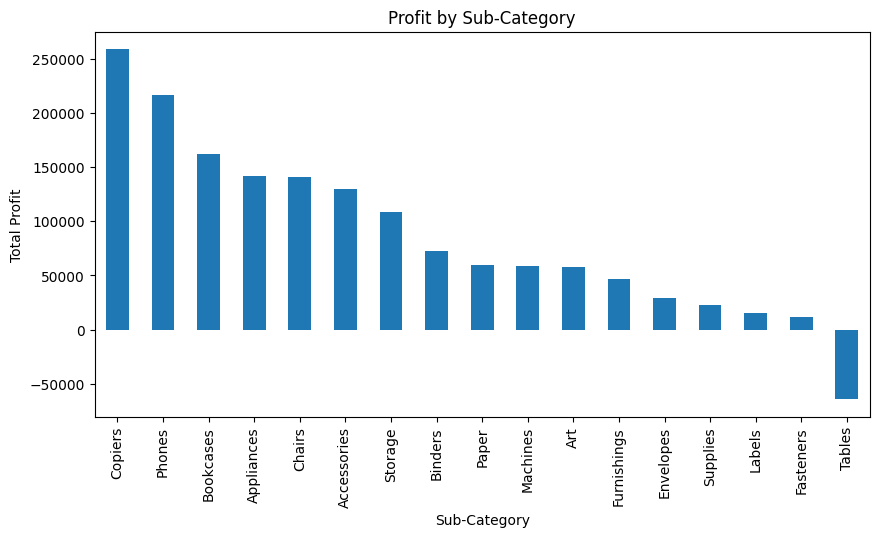

In [49]:
profit_by_subcategory.plot(
    kind="bar",
    figsize=(10, 5),
    title="Profit by Sub-Category",
    xlabel="Sub-Category",
    ylabel="Total Profit"
)

<Axes: title={'center': 'Profit by Region'}, xlabel='Region', ylabel='Total Profit'>

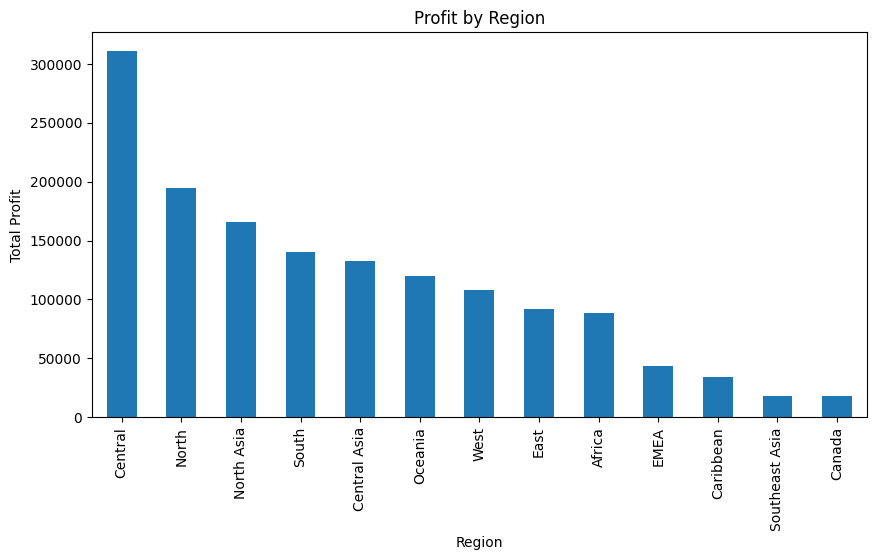

In [50]:
profit_by_region.plot(
    kind="bar",
    figsize=(10, 5),
    title="Profit by Region",
    xlabel="Region",
    ylabel="Total Profit"
)

In [51]:
discount_profit = (
    df.groupby("Discount")["Profit"]
    .agg(["sum", "mean", "count"])
    .sort_index()
)

discount_profit

,sum,mean,count
Discount,,,
0.000,1.770695e+06,61.039514,29009
0.002,5.797658e+04,125.762649,461
0.070,2.114850e+04,140.990022,150
0.100,2.590642e+05,63.683426,4068
0.150,2.737590e+04,50.602409,541
0.170,2.816307e+04,38.317107,735
0.200,1.177159e+05,23.552594,4998
0.202,-5.952727e+02,-14.518847,41
0.250,8.005875e+02,4.043371,198


<Axes: title={'center': 'Average Profit by Discount'}, xlabel='Discount', ylabel='Average Profit'>

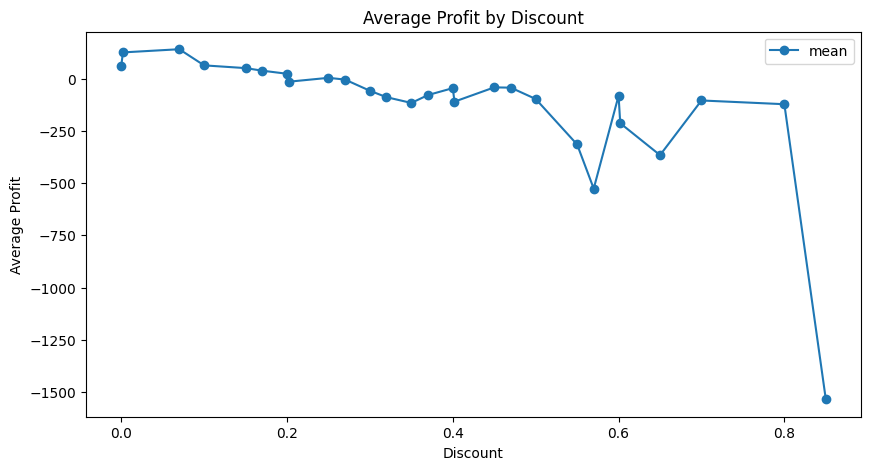

In [52]:
discount_profit.plot(
    y="mean",
    kind="line",
    marker="o",
    figsize=(10, 5),
    title="Average Profit by Discount",
    xlabel="Discount",
    ylabel="Average Profit"
)

In [53]:
profit_by_category = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_category

Category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          285204.72380
Name: Profit, dtype: float64

In [54]:
profit_by_subcategory = (
    df.groupby("Sub.Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_subcategory

Sub.Category
Copiers        258567.54818
Phones         216717.00580
Bookcases      161924.41950
Appliances     141680.58940
Chairs         140396.26750
Accessories    129626.30620
Storage        108461.48980
Binders         72449.84600
Paper           59207.68270
Machines        58867.87300
Art             57953.91090
Furnishings     46967.42550
Envelopes       29601.11630
Supplies        22583.26310
Labels          15010.51200
Fasteners       11525.42410
Tables         -64083.38870
Name: Profit, dtype: float64

In [55]:
most_profitable = profit_by_subcategory.idxmax()
most_profit = profit_by_subcategory.max()

least_profitable = profit_by_subcategory.idxmin()
least_profit = profit_by_subcategory.min()

print("Most profitable:", most_profitable, "-", most_profit)
print("Least profitable:", least_profitable, "-", least_profit)

Most profitable: Copiers - 258567.54818
Least profitable: Tables - -64083.3887


In [56]:
profit_by_region = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_region

Region
Central           311403.98164
North             194597.95252
North Asia        165578.42100
South             140355.76618
Central Asia      132480.18700
Oceania           120089.11200
West              108418.44890
East               91522.78000
Africa             88871.63100
EMEA               43897.97100
Caribbean          34571.32104
Southeast Asia     17852.32900
Canada             17817.39000
Name: Profit, dtype: float64

<Axes: title={'center': 'Profit by Region'}, xlabel='Region', ylabel='Total Profit'>

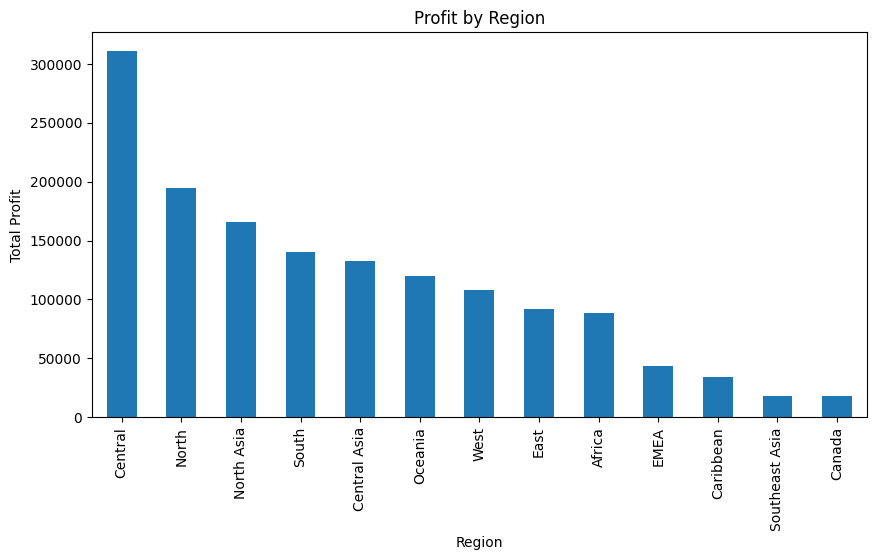

In [57]:
profit_by_region.plot(
    kind="bar",
    figsize=(10, 5),
    title="Profit by Region",
    xlabel="Region",
    ylabel="Total Profit"
)

In [58]:
category_performance = (
    df.groupby("Category")[["Sales", "Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

category_performance

,Sales,Profit
Category,,
Technology,4744691,663778.73318
Furniture,4110884,285204.72380
Office Supplies,3787330,518473.83430


<Axes: title={'center': 'Sales vs Profit by Category'}, xlabel='Category', ylabel='Amount'>

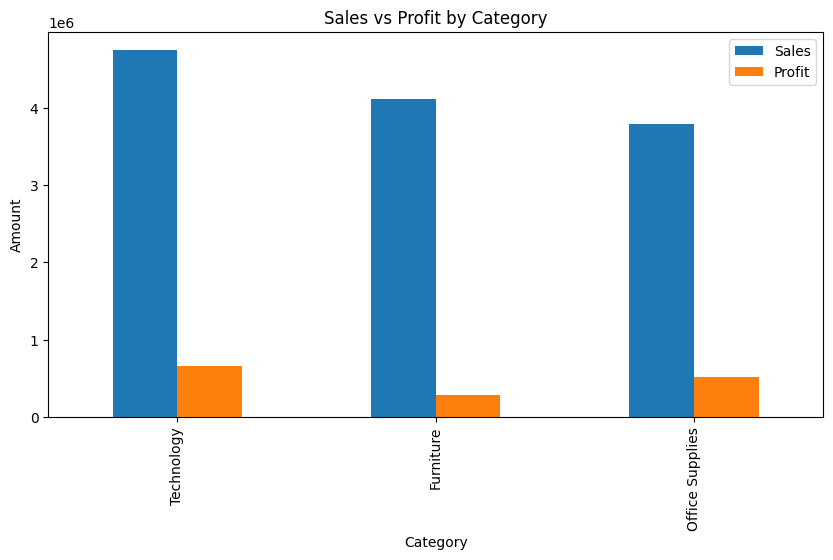

In [59]:
category_performance.plot(
    kind="bar",
    figsize=(10, 5),
    title="Sales vs Profit by Category",
    xlabel="Category",
    ylabel="Amount"
)

In [60]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

profit_margin = (total_profit / total_sales) * 100

print("Overall Profit Margin:", round(profit_margin, 2), "%")

Overall Profit Margin: 11.61 %


In [61]:
category_performance["Profit_Margin_%"] = (
    category_performance["Profit"] /
    category_performance["Sales"] * 100
)

category_performance

,Sales,Profit,Profit_Margin_%
Category,,,
Technology,4744691,663778.73318,13.989925
Furniture,4110884,285204.72380,6.937795
Office Supplies,3787330,518473.83430,13.689693


In [62]:
segment_analysis = (
    df.groupby("Segment")[["Sales", "Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

segment_analysis

,Sales,Profit
Segment,,
Consumer,6508141,749239.78206
Corporate,3824808,441208.32866
Home Office,2309956,277009.18056


<Axes: title={'center': 'Sales and Profit by Customer Segment'}, xlabel='Customer Segment', ylabel='Amount'>

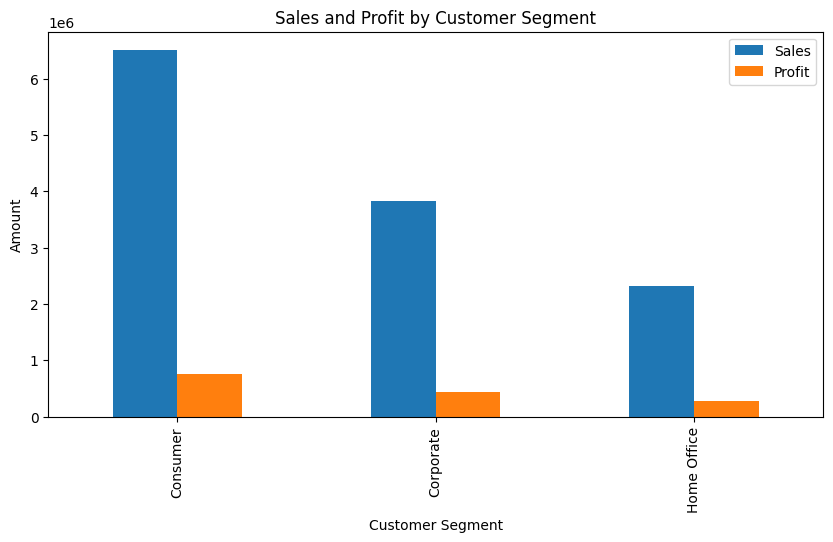

In [63]:
segment_analysis.plot(
    kind="bar",
    figsize=(10, 5),
    title="Sales and Profit by Customer Segment",
    xlabel="Customer Segment",
    ylabel="Amount"
)

In [64]:
region_performance = (
    df.groupby("Region")[["Sales", "Profit"]]
    .sum()
)

region_performance["Profit_Margin_%"] = (
    region_performance["Profit"] /
    region_performance["Sales"] * 100
)

region_performance = region_performance.sort_values(
    "Sales", ascending=False
)

region_performance

,Sales,Profit,Profit_Margin_%
Region,,,
Central,2822399,311403.98164,11.033308
South,1600960,140355.76618,8.766975
North,1248192,194597.95252,15.590386
Oceania,1100207,120089.11200,10.915138
Southeast Asia,884438,17852.32900,2.018494
North Asia,848349,165578.42100,19.517725
EMEA,806184,43897.97100,5.445155
Africa,783776,88871.63100,11.338907
Central Asia,752839,132480.18700,17.597413


In [65]:
best_sales_region = region_performance["Sales"].idxmax()

print("Highest Sales Region:", best_sales_region)

Highest Sales Region: Central


In [66]:
best_profit_region = region_performance["Profit"].idxmax()

print("Highest Profit Region:", best_profit_region)

Highest Profit Region: Central


<Axes: title={'center': 'Sales by Region'}, xlabel='Region', ylabel='Total Sales'>

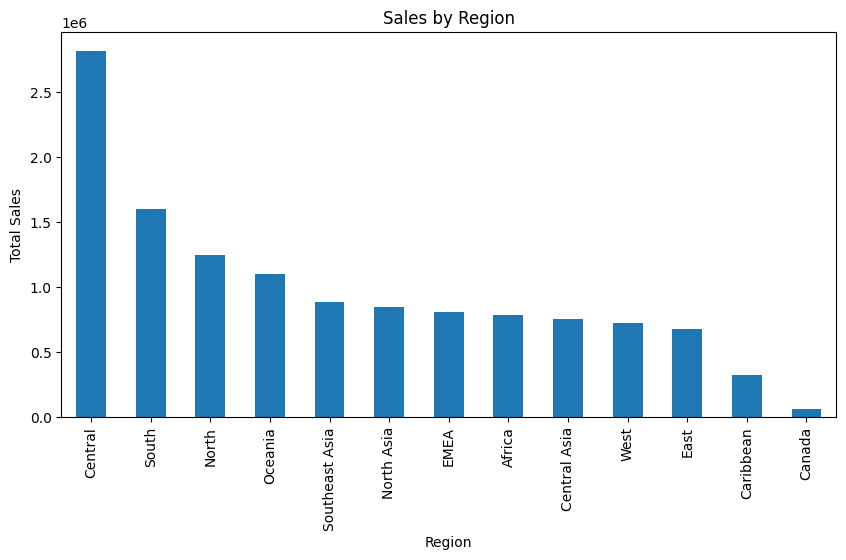

In [67]:
region_performance["Sales"].plot(
    kind="bar",
    figsize=(10, 5),
    title="Sales by Region",
    xlabel="Region",
    ylabel="Total Sales"
)

In [68]:
customer_segment = (
    df.groupby("Segment")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Customers=("Customer.ID", "nunique")
    )
)

customer_segment

,Sales,Profit,Customers
Segment,,,
Consumer,6508141,749239.78206,2509
Corporate,3824808,441208.32866,1457
Home Office,2309956,277009.18056,907


In [69]:
customer_segment["Sales_per_Customer"] = (
    customer_segment["Sales"] /
    customer_segment["Customers"]
)

customer_segment

,Sales,Profit,Customers,Sales_per_Customer
Segment,,,,
Consumer,6508141,749239.78206,2509,2593.918294
Corporate,3824808,441208.32866,1457,2625.125601
Home Office,2309956,277009.18056,907,2546.809261


In [70]:
discount_analysis = (
    df.groupby("Discount")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Avg_Profit=("Profit", "mean"),
        Orders=("Order.ID", "nunique")
    )
    .sort_index()
)

discount_analysis

,Sales,Profit,Avg_Profit,Orders
Discount,,,,
0.000,6992734,1.770695e+06,61.039514,15211
0.002,261395,5.797658e+04,125.762649,437
0.070,121620,2.114850e+04,140.990022,135
0.100,1579618,2.590642e+05,63.683426,2456
0.150,306037,2.737590e+04,50.602409,477
0.170,247404,2.816307e+04,38.317107,519
0.200,1203855,1.177159e+05,23.552594,3389
0.202,16213,-5.952727e+02,-14.518847,39
0.250,88063,8.005875e+02,4.043371,154


In [71]:
discount_analysis["Profit_Margin_%"] = (
    discount_analysis["Profit"] /
    discount_analysis["Sales"] * 100
)

discount_analysis

,Sales,Profit,Avg_Profit,Orders,Profit_Margin_%
Discount,,,,,
0.000,6992734,1.770695e+06,61.039514,15211,25.321931
0.002,261395,5.797658e+04,125.762649,437,22.179683
0.070,121620,2.114850e+04,140.990022,135,17.389001
0.100,1579618,2.590642e+05,63.683426,2456,16.400432
0.150,306037,2.737590e+04,50.602409,477,8.945292
0.170,247404,2.816307e+04,38.317107,519,11.383435
0.200,1203855,1.177159e+05,23.552594,3389,9.778243
0.202,16213,-5.952727e+02,-14.518847,39,-3.671577
0.250,88063,8.005875e+02,4.043371,154,0.909108


<Axes: title={'center': 'Profit Margin vs Discount'}, xlabel='Discount', ylabel='Profit Margin (%)'>

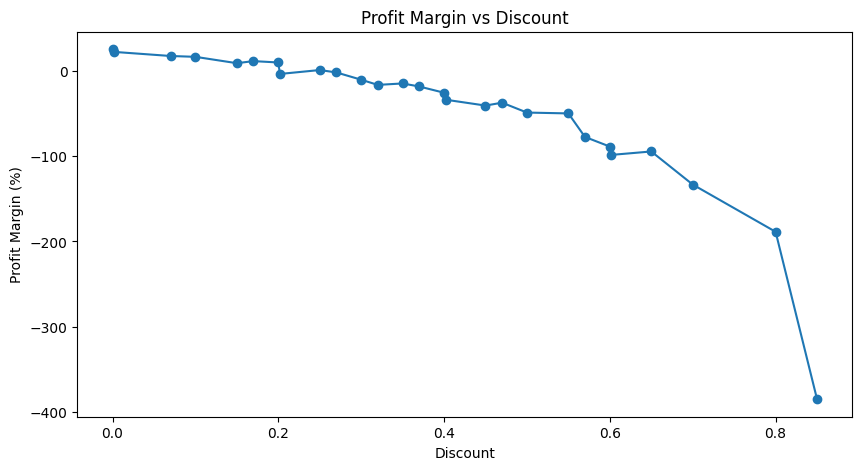

In [72]:
discount_analysis["Profit_Margin_%"].plot(
    kind="line",
    marker="o",
    figsize=(10, 5),
    title="Profit Margin vs Discount",
    xlabel="Discount",
    ylabel="Profit Margin (%)"
)

In [73]:
print("===== SALES PERFORMANCE KPIs =====")
print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Quantity Sold:", total_quantity)
print("Profit Margin:", round(profit_margin, 2), "%")
print("Top Product:", top_products.index[0])
print("Top Category:", category_sales.index[0])
print("Top Region by Sales:", region_performance["Sales"].idxmax())
print("Top Customer Segment:", customer_segment["Sales"].idxmax())

===== SALES PERFORMANCE KPIs =====
Total Sales: 12642905
Total Profit: 1467457.2912800002
Total Quantity Sold: 178312
Profit Margin: 11.61 %
Top Product: Apple Smart Phone, Full Size
Top Category: Technology
Top Region by Sales: Central
Top Customer Segment: Consumer


In [74]:
df.to_csv("Global_Superstore_Cleaned.csv", index=False)

In [75]:
df.shape

(51290, 29)

In [76]:
import os
os.getcwd()

'C:\\Users\\sreel\\Downloads\\Retail_Sales_Analysis'

In [77]:
os.listdir()

['.ipynb_checkpoints',
 'Global_Superstore.csv',
 'Global_Superstore_Cleaned.csv',
 'Retail_Sales_Analysis.ipynb']

In [78]:
print("===== KEY BUSINESS INSIGHTS =====")

print("\n1. Overall KPIs")
print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Quantity:", total_quantity)
print("Profit Margin:", round(profit_margin, 2), "%")

print("\n2. Top Product")
print(top_products.index[0], "→", top_products.iloc[0])

print("\n3. Top Category by Sales")
print(category_sales.index[0], "→", category_sales.iloc[0])

print("\n4. Top Category by Profit")
print(profit_by_category.index[0], "→", profit_by_category.iloc[0])

print("\n5. Best Region by Sales")
print(region_performance["Sales"].idxmax(), "→",
      region_performance["Sales"].max())

print("\n6. Best Region by Profit")
print(region_performance["Profit"].idxmax(), "→",
      region_performance["Profit"].max())

print("\n7. Best Customer Segment")
print(customer_segment["Sales"].idxmax(), "→",
      customer_segment["Sales"].max())

print("\n8. Peak Sales Month")
print(peak_month["Month_Name"], "→", peak_month["Sales"])

print("\n9. Lowest Sales Month")
print(lowest_month["Month_Name"], "→", lowest_month["Sales"])

print("\n10. Most Profitable Sub-Category")
print(most_profitable, "→", most_profit)

print("\n11. Least Profitable Sub-Category")
print(least_profitable, "→", least_profit)

===== KEY BUSINESS INSIGHTS =====

1. Overall KPIs
Total Sales: 12642905
Total Profit: 1467457.2912800002
Total Quantity: 178312
Profit Margin: 11.61 %

2. Top Product
Apple Smart Phone, Full Size → 86936

3. Top Category by Sales
Technology → 4744691

4. Top Category by Profit
Technology → 663778.73318

5. Best Region by Sales
Central → 2822399

6. Best Region by Profit
Central → 311403.98164

7. Best Customer Segment
Consumer → 6508141

8. Peak Sales Month
December → 1580816

9. Lowest Sales Month
February → 543768

10. Most Profitable Sub-Category
Copiers → 258567.54818

11. Least Profitable Sub-Category
Tables → -64083.3887


In [79]:
top_customers = (
    df.groupby("Customer.Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

Customer.Name
Tom Ashbrook          40489
Tamara Chand          37453
Greg Tran             35552
Christopher Conant    35187
Sean Miller           35170
Bart Watters          32315
Natalie Fritzler      31778
Fred Hopkins          30404
Jane Waco             30288
Hunter Lopez          30246
Name: Sales, dtype: int64

<Axes: title={'center': 'Top 10 Customers by Sales'}, xlabel='Total Sales', ylabel='Customer'>

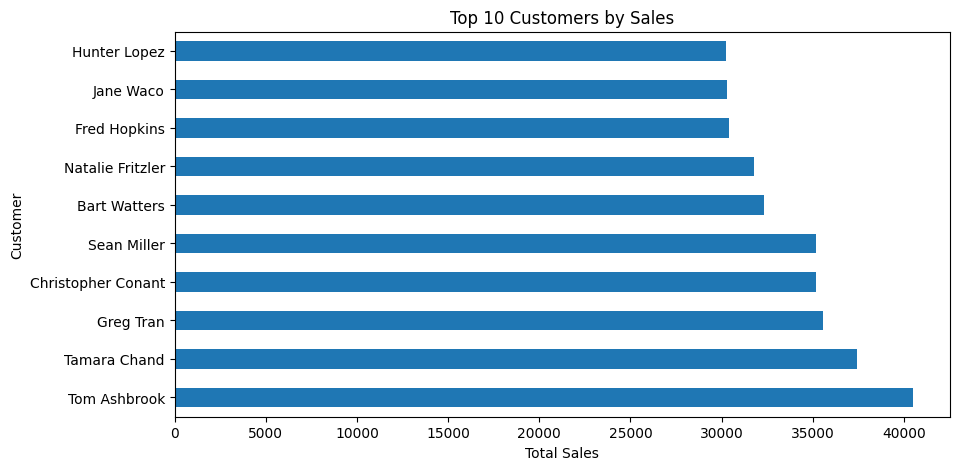

In [80]:
top_customers.plot(
    kind="barh",
    figsize=(10, 5),
    title="Top 10 Customers by Sales",
    xlabel="Total Sales",
    ylabel="Customer"
)

In [82]:
yearly_sales = (
    df.groupby("Year")["Sales"]
    .sum()
    .sort_index()
)

yearly_growth = yearly_sales.pct_change() * 100

yearly_growth

Year
2011          NaN
2012    18.498781
2013    27.203320
2014    26.254191
Name: Sales, dtype: float64

In [83]:
highest_growth_year = yearly_growth.idxmax()
highest_growth = yearly_growth.max()

print(
    "Highest Sales Growth:",
    highest_growth_year,
    "→",
    round(highest_growth, 2),
    "%"
)

Highest Sales Growth: 2013 → 27.2 %


In [84]:
lowest_growth_year = yearly_growth.idxmin()
lowest_growth = yearly_growth.min()

print(
    "Lowest Sales Growth:",
    lowest_growth_year,
    "→",
    round(lowest_growth, 2),
    "%"
)

Lowest Sales Growth: 2012 → 18.5 %


<Axes: title={'center': 'Year-over-Year Sales Growth'}, xlabel='Year', ylabel='Growth (%)'>

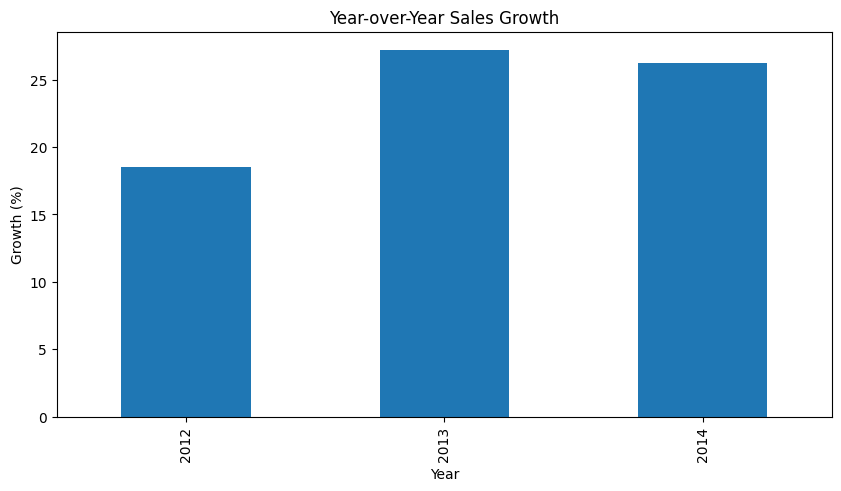

In [85]:
yearly_growth.dropna().plot(
    kind="bar",
    figsize=(10, 5),
    title="Year-over-Year Sales Growth",
    xlabel="Year",
    ylabel="Growth (%)"
)

In [86]:
summary = {
    "Total Sales": total_sales,
    "Total Profit": total_profit,
    "Profit Margin (%)": round(profit_margin, 2),
    "Top Product": top_products.index[0],
    "Top Category": category_sales.index[0],
    "Top Sales Region": region_performance["Sales"].idxmax(),
    "Top Profit Region": region_performance["Profit"].idxmax(),
    "Top Customer Segment": customer_segment["Sales"].idxmax(),
    "Peak Sales Month": peak_month["Month_Name"],
    "Lowest Sales Month": lowest_month["Month_Name"],
    "Most Profitable Sub-Category": most_profitable,
    "Least Profitable Sub-Category": least_profitable,
    "Highest Growth Year": highest_growth_year
}

summary

{'Total Sales': np.int64(12642905),
 'Total Profit': np.float64(1467457.2912800002),
 'Profit Margin (%)': np.float64(11.61),
 'Top Product': 'Apple Smart Phone, Full Size',
 'Top Category': 'Technology',
 'Top Sales Region': 'Central',
 'Top Profit Region': 'Central',
 'Top Customer Segment': 'Consumer',
 'Peak Sales Month': 'December',
 'Lowest Sales Month': 'February',
 'Most Profitable Sub-Category': 'Copiers',
 'Least Profitable Sub-Category': 'Tables',
 'Highest Growth Year': np.int64(2013)}

In [87]:
discount_analysis[["Sales", "Profit", "Profit_Margin_%"]]

,Sales,Profit,Profit_Margin_%
Discount,,,
0.000,6992734,1.770695e+06,25.321931
0.002,261395,5.797658e+04,22.179683
0.070,121620,2.114850e+04,17.389001
0.100,1579618,2.590642e+05,16.400432
0.150,306037,2.737590e+04,8.945292
0.170,247404,2.816307e+04,11.383435
0.200,1203855,1.177159e+05,9.778243
0.202,16213,-5.952727e+02,-3.671577
0.250,88063,8.005875e+02,0.909108


In [88]:
discount_analysis["Profit_Margin_%"].corr(
    discount_analysis.index.to_series()
)

np.float64(-0.840279073148191)

In [89]:
top_profit_products = (
    df.groupby("Product.Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_profit_products

Product.Name
Canon imageCLASS 2200 Advanced Copier                       25199.9280
Cisco Smart Phone, Full Size                                17238.5206
Motorola Smart Phone, Full Size                             17027.1130
Hoover Stove, Red                                           11807.9690
Sauder Classic Bookcase, Traditional                        10672.0730
Harbour Creations Executive Leather Armchair, Adjustable    10427.3260
Nokia Smart Phone, Full Size                                 9938.1955
Cisco Smart Phone, with Caller ID                            9786.6408
Nokia Smart Phone, with Caller ID                            9465.3257
Belkin Router, USB                                           8955.0180
Name: Profit, dtype: float64

In [90]:
bottom_profit_products = (
    df.groupby("Product.Name")["Profit"]
    .sum()
    .sort_values()
    .head(10)
)

bottom_profit_products

Product.Name
Cubify CubeX 3D Printer Double Head Print                  -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                  -4589.9730
Motorola Smart Phone, Cordless                             -4447.0380
Cubify CubeX 3D Printer Triple Head Print                  -3839.9904
Bevis Round Table, Adjustable Height                       -3649.8940
Bevis Computer Table, Fully Assembled                      -3509.5638
Rogers Lockers, Blue                                       -2893.4908
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases   -2876.1156
Bevis Wood Table, with Bottom Storage                      -2782.5880
Lesro Training Table, Rectangular                          -2581.2834
Name: Profit, dtype: float64

<Axes: title={'center': 'Sales vs Profit by Category'}, xlabel='Category', ylabel='Amount'>

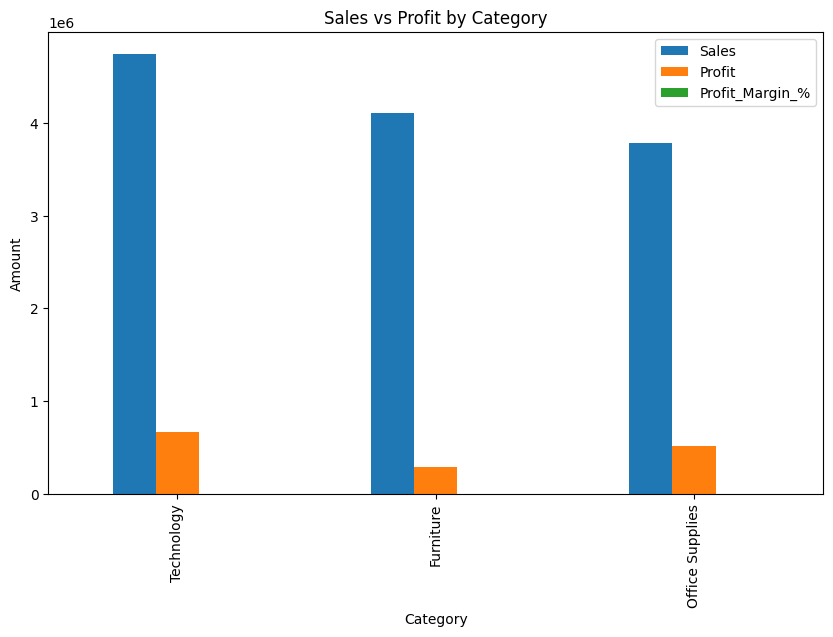

In [91]:
category_performance.plot(
    kind="bar",
    figsize=(10, 6),
    title="Sales vs Profit by Category",
    xlabel="Category",
    ylabel="Amount"
)

In [92]:
print("========== FINAL PROJECT RESULTS ==========")

print("\nTOTAL KPIs")
print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Quantity:", total_quantity)
print("Profit Margin:", round(profit_margin, 2), "%")

print("\nPRODUCT")
print("Top Product by Sales:", top_products.index[0])
print("Top Product Sales:", top_products.iloc[0])

print("\nCATEGORY")
print("Top Category by Sales:", category_sales.index[0])
print("Top Category Sales:", category_sales.iloc[0])
print("Top Category by Profit:", profit_by_category.index[0])
print("Top Category Profit:", profit_by_category.iloc[0])

print("\nREGION")
print("Top Region by Sales:", region_performance["Sales"].idxmax())
print("Top Region Sales:", region_performance["Sales"].max())
print("Top Region by Profit:", region_performance["Profit"].idxmax())
print("Top Region Profit:", region_performance["Profit"].max())

print("\nCUSTOMER")
print("Top Customer Segment:", customer_segment["Sales"].idxmax())
print("Top Segment Sales:", customer_segment["Sales"].max())

print("\nTIME")
print("Peak Sales Month:", peak_month["Month_Name"])
print("Peak Month Sales:", peak_month["Sales"])
print("Lowest Sales Month:", lowest_month["Month_Name"])
print("Lowest Month Sales:", lowest_month["Sales"])

print("\nPROFITABILITY")
print("Most Profitable Sub-Category:", most_profitable)
print("Profit:", most_profit)
print("Least Profitable Sub-Category:", least_profitable)
print("Profit:", least_profit)

print("\nGROWTH")
print("Highest Growth Year:", highest_growth_year)
print("Highest Growth:", round(highest_growth, 2), "%")
print("Lowest Growth Year:", lowest_growth_year)
print("Lowest Growth:", round(lowest_growth, 2), "%")

========== FINAL PROJECT RESULTS ==========

TOTAL KPIs
Total Sales: 12642905
Total Profit: 1467457.2912800002
Total Quantity: 178312
Profit Margin: 11.61 %

PRODUCT
Top Product by Sales: Apple Smart Phone, Full Size
Top Product Sales: 86936

CATEGORY
Top Category by Sales: Technology
Top Category Sales: 4744691
Top Category by Profit: Technology
Top Category Profit: 663778.73318

REGION
Top Region by Sales: Central
Top Region Sales: 2822399
Top Region by Profit: Central
Top Region Profit: 311403.98164

CUSTOMER
Top Customer Segment: Consumer
Top Segment Sales: 6508141

TIME
Peak Sales Month: December
Peak Month Sales: 1580816
Lowest Sales Month: February
Lowest Month Sales: 543768

PROFITABILITY
Most Profitable Sub-Category: Copiers
Profit: 258567.54818
Least Profitable Sub-Category: Tables
Profit: -64083.3887

GROWTH
Highest Growth Year: 2013
Highest Growth: 27.2 %
Lowest Growth Year: 2012
Lowest Growth: 18.5 %
